
--- Testing with AlexNet ---
Prediction: Purse
Confidence: 39.0%


--- Testing with VGG16 ---
Prediction: Swing
Confidence: 99.8%


--- Testing with ResNet50 ---
Prediction: Swing
Confidence: 74.2%


--- Testing with MobileNet V2 ---
Prediction: Swing
Confidence: 27.6%



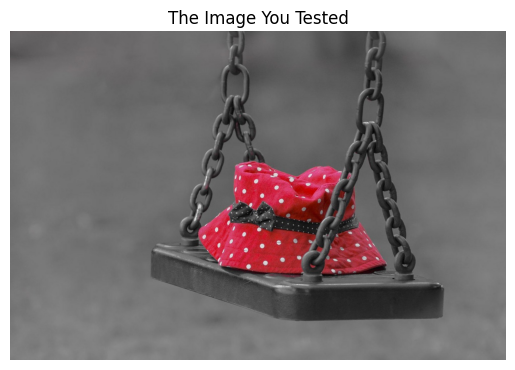

In [37]:
# --- STEP 1: BRING IN THE TOOLS ---
import torch  # This brings in the main PyTorch library for AI math.
import torchvision.transforms.functional as F  # This brings in tools to edit pictures.
from torchvision.io import read_image  # This brings in the tool to open an image file.
import torchvision.models as models  # This brings in the famous pre-trained AI models.
import matplotlib.pyplot as plt  # This brings in the tool to draw graphs and show images on screen.

# --- STEP 2: LOAD YOUR IMAGE ---
# We save the exact location of your Kaggle image inside a variable.
image_path = "/kaggle/input/datasets/rafayraza1nextgen/img-jpg/publicdomainpictures-forgotten-214772_1280.jpg"

# We use the read_image tool to actually open the picture and turn it into math numbers.
my_image = read_image(image_path)

# --- STEP 3: PREPARE THE MODELS ---
# We create a dictionary (a list of pairs) with the names of the models and their smartest weights.
models_to_test = {
    "AlexNet": (models.alexnet, models.AlexNet_Weights.DEFAULT),
    "VGG16": (models.vgg16, models.VGG16_Weights.DEFAULT),
    "ResNet50": (models.resnet50, models.ResNet50_Weights.DEFAULT),
    "MobileNet V2": (models.mobilenet_v2, models.MobileNet_V2_Weights.DEFAULT)
}

# --- STEP 4: TEST EACH MODEL ONE BY ONE ---
# This loop will run four times (once for each model in our list above).
for model_name, (model_function, model_weights) in models_to_test.items():
    
    # We print a dividing line and the model's name so it is easy to read the output.
    print(f"\n--- Testing with {model_name} ---")
    
    # We load the specific model and give it the pre-trained weights so it is smart.
    model = model_function(weights=model_weights)
    
    # We put the model in "evaluation" mode to lock its brain so it just guesses and doesn't learn.
    model.eval()
    
    # We ask the weights tool to give us the exact editing instructions this specific model needs.
    preprocess = model_weights.transforms()
    
    # We resize the image and wrap it in a fake "batch" list because the model expects a group.
    batch = preprocess(my_image).unsqueeze(0)
    
    # We tell PyTorch to stop tracking the math used for learning, which saves computer memory.
    with torch.no_grad():
        
        # The model looks at the image batch, removes the batch wrapper, and turns the score into percentages.
        prediction = model(batch).squeeze(0).softmax(0)
        
    # We search the 1,000 percentages to find the ID number of the highest score.
    winning_id = prediction.argmax().item()
    
    # We use that winning ID number to grab the actual winning percentage score.
    winning_score = prediction[winning_id].item()
    
    # We open the built-in dictionary to translate the winning ID number into a real English word.
    category_name = model_weights.meta["categories"][winning_id]
    
    # We print the final result on the screen, showing the percentage out of 100.
    print(f"Prediction: {category_name.title()}")
    print(f"Confidence: {100 * winning_score:.1f}%\n")

# --- STEP 5: SHOW THE IMAGE AT THE END ---
# We convert the math version of the image back into a normal picture format.
image_to_show = F.to_pil_image(my_image)

# We tell the plotting tool to load the picture.
plt.imshow(image_to_show)

# We turn off the grid lines and numbers around the picture.
plt.axis("off")

# We add a title to the top of the picture.
plt.title("The Image You Tested")

# We finally tell the plotting tool to show everything on the screen.
plt.show()

100%|██████████| 170M/170M [23:14<00:00, 122kB/s]  



 TESTING IMAGE NUMBER 1
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 141MB/s]  


AlexNet Guesses: Fox Squirrel (8.2%)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 156MB/s] 


VGG16 Guesses: Pickelhaube (7.7%)
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 151MB/s]


ResNet50 Guesses: Can Opener (3.8%)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 109MB/s] 


MobileNet V2 Guesses: Bluetick (5.4%)


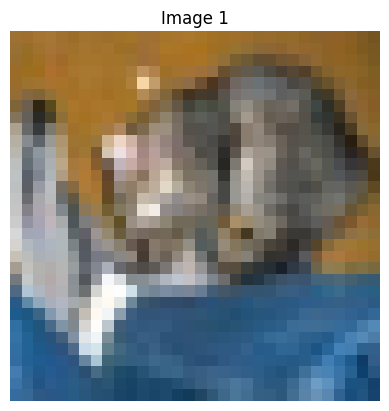


 TESTING IMAGE NUMBER 2
AlexNet Guesses: Moving Van (8.6%)
VGG16 Guesses: Sunscreen (21.3%)
ResNet50 Guesses: Oil Filter (7.5%)
MobileNet V2 Guesses: Speedboat (10.7%)


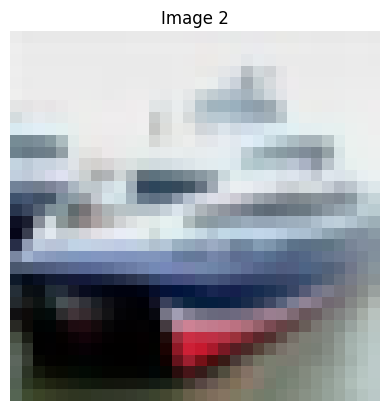


 TESTING IMAGE NUMBER 3
AlexNet Guesses: Amphibian (17.1%)
VGG16 Guesses: Yawl (49.9%)
ResNet50 Guesses: Amphibian (13.7%)
MobileNet V2 Guesses: Moving Van (4.0%)


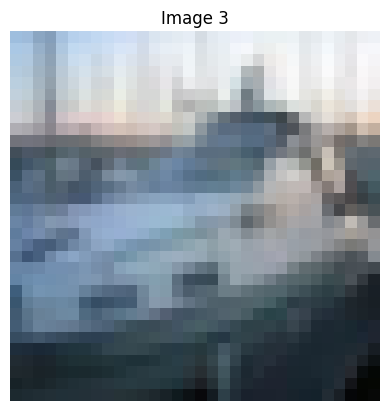

In [1]:
# --- STEP 1: BRING IN THE TOOLS ---
import torch  # The main AI math tool
import torchvision.datasets as datasets  # The tool to download ready-made datasets
import torchvision.models as models  # The tool to load our 4 models
import matplotlib.pyplot as plt  # The tool to show pictures on the screen

# --- STEP 2: DOWNLOAD THE DATASET ---
print("Downloading the dataset from the internet... (This takes just a few seconds)")

# We download the CIFAR-10 dataset and save it into a folder named 'data'.
# download=True tells Python to do all the hard work of fetching it for us.
dataset = datasets.CIFAR10(root='./data', train=False, download=True)

# --- STEP 3: PREPARE THE 4 MODELS ---
# We put all four models and their smartest weights into a list so we can loop through them.
models_to_test = {
    "AlexNet": (models.alexnet, models.AlexNet_Weights.DEFAULT),
    "VGG16": (models.vgg16, models.VGG16_Weights.DEFAULT),
    "ResNet50": (models.resnet50, models.ResNet50_Weights.DEFAULT),
    "MobileNet V2": (models.mobilenet_v2, models.MobileNet_V2_Weights.DEFAULT)
}

# --- STEP 4: GRAB A FEW IMAGES TO TEST ---
# dataset[0][0] gets the very first picture. dataset[1][0] gets the second, and so on.
# We will just take 3 pictures so the output isn't too long.
images_to_test = [dataset[0][0], dataset[1][0], dataset[2][0]]

# --- STEP 5: RUN THE TEST ---
# This outer loop goes through our 3 pictures one by one.
for i, my_image in enumerate(images_to_test):
    
    # Print a nice header so we know which picture we are looking at.
    print(f"\n=========================================")
    print(f" TESTING IMAGE NUMBER {i + 1}")
    print(f"=========================================")
    
    # This inner loop goes through all 4 models for the current picture.
    for model_name, (model_function, model_weights) in models_to_test.items():
        
        # Load the model and make it smart with pre-trained weights.
        model = model_function(weights=model_weights)
        
        # Lock the model's brain so it only guesses and does not try to learn.
        model.eval()
        
        # Get the exact editing instructions this specific model needs.
        preprocess = model_weights.transforms()
        
        # Edit the image and wrap it in a fake "batch" list.
        batch = preprocess(my_image).unsqueeze(0)
        
        # Stop tracking math to save computer memory.
        with torch.no_grad():
            # The model guesses and turns the math into percentages.
            prediction = model(batch).squeeze(0).softmax(0)
            
        # Find the ID number of the highest score.
        winning_id = prediction.argmax().item()
        
        # Use the ID number to get the actual percentage score.
        winning_score = prediction[winning_id].item()
        
        # Translate the ID number into a real English word.
        category_name = model_weights.meta["categories"][winning_id]
        
        # Print what this specific model guessed.
        print(f"{model_name} Guesses: {category_name.title()} ({100 * winning_score:.1f}%)")
        
    # After all 4 models have guessed, show the picture on the screen!
    plt.imshow(my_image)
    plt.axis("off") # Turn off the graph lines
    plt.title(f"Image {i + 1}")
    plt.show()